In [2]:
import numpy as np
import matplotlib.pyplot as plt

(101,) (101, 1)


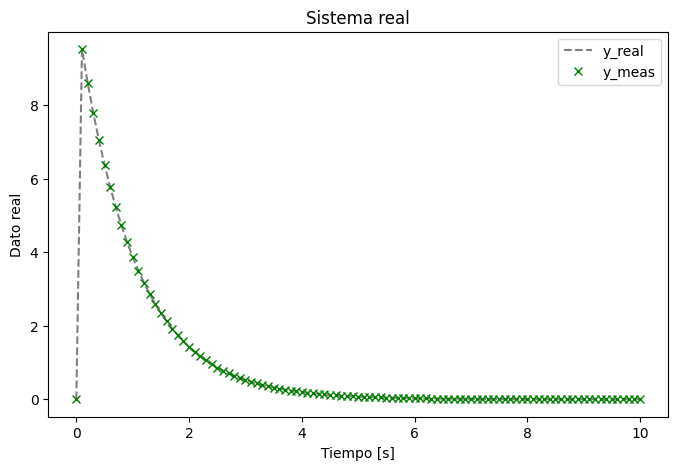

In [3]:
# Primero simulemos el sistema "real"
M = 101
delta = 0.1
std = 0.

y = np.zeros((M,1))
y_meas = np.zeros((M,1))
u = np.zeros((M,1))
u[0,:] = 100

# PHI - GAMMA
x = [0.9048, 0.0952] # Coeficientes de las h (en este caso, y-u)

for j in range(1,M):
    y[j] = x[0] * y[j-1] + x[1] * u[j-1]
    y_meas[j] = y[j] + np.random.normal(0, std)

t = np.arange(M) * delta
print(t.shape, y_meas.shape)

plt.figure(figsize=(8,5))
plt.title("Sistema real")
plt.xlabel("Tiempo [s]")
plt.ylabel("Dato real")
plt.plot(t, y, '--', c='gray', label='y_real')
plt.plot(t, y_meas, 'x', c='green', label='y_meas')
plt.legend()
plt.show()

In [4]:
# La idea es trabajar con el x_est previo para
# actualizarlo con el dato nuevo

# x_est contendrá la aproximación por iteración
# El H y el W corresponden al subconjunto de mediciones y_2 (el nuevo)

x_est = np.zeros((len(x),M)) 
x_est[:,0] = [10.010, 0.014]
P_k = np.array([
    [1.000e6, 1.038e3],
    [1.038e3, 1.077e0]
])

for it in range(1, y_meas.shape[0]): # it = k+1
    # Definimos H_k+1 y W_k+1
    H = np.hstack((y_meas[it-1], u[it-1])).reshape(1,-1)
    W = np.array([[1]])

    # Actualizamos P_k+1 y K_k+1 antes de hacer x_k+1
    P_k_inv = np.linalg.inv(P_k) + H.T @ W @ H
    P_k = np.linalg.inv(P_k_inv)
    K = P_k @ H.T @ W

    x_k = x_est[:, it-1]
    x_est[:,it] = x_k + K @ (y_meas[it] - H @ x_k)
print(f"X_real: {x}")
print(f"X_est final: {x_est[:,-1].flatten()}")

X_real: [0.9048, 0.0952]
X_est final: [0.90425272 0.12155226]


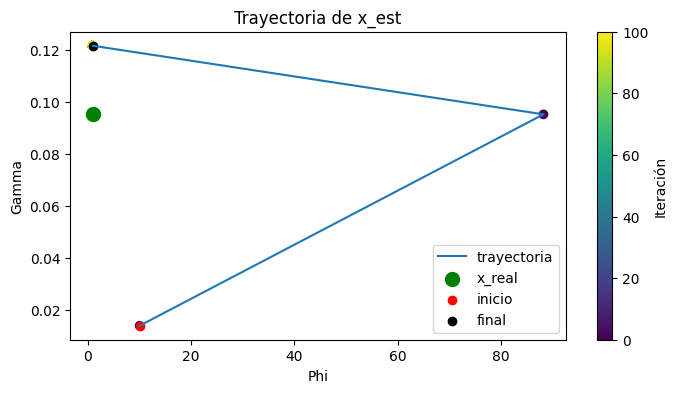

In [5]:
plt.figure(figsize=(8,4))
plt.title("Trayectoria de x_est")
plt.xlabel("Phi")
plt.ylabel("Gamma")

# trayectoria
plt.plot(x_est[0,:], x_est[1,:], '-', markersize=3, label='trayectoria')

# color por iteración
c = np.arange(M)
sc = plt.scatter(x_est[0,:], x_est[1,:], c=c, cmap='viridis')

# puntos clave
plt.scatter(x[0], x[1], c='green', label='x_real', s=100)
plt.scatter(x_est[0,0], x_est[1,0], c='red', label='inicio')
plt.scatter(x_est[0,-1], x_est[1,-1], c='black', label='final')

plt.colorbar(sc, label='Iteración')
plt.legend()
plt.show()

In [6]:
# Probamos con las fórmulas 1.78 -> 1.80

x_est = np.zeros((len(x),M)) 
x_est[:,0] = [10.010, 0.014]
P_k = np.array([
    [1.000e6, 1.038e3],
    [1.038e3, 1.077e0]
])

for it in range(1, y_meas.shape[0]): # it = k+1
    # Definimos H_k+1 y W_k+1
    H = np.hstack((y_meas[it-1], u[it-1])).reshape(1,-1)
    W = np.array([[1]])

    # Actualizamos P_k+1 y K_k+1 antes de hacer x_k+1
    K = P_k @ H.T @ np.linalg.inv(H @ P_k @ H.T + np.linalg.inv(W))
    P_k = (np.eye(P_k.shape[0]) - K @ H) @ P_k

    x_k = x_est[:, it-1]
    x_est[:,it] = x_k + K @ (y_meas[it] - H @ x_k)
    
print(f"X_real: {x}")
print(f"X_est final: {x_est[:,-1].flatten()}")

X_real: [0.9048, 0.0952]
X_est final: [0.90425272 0.12155226]


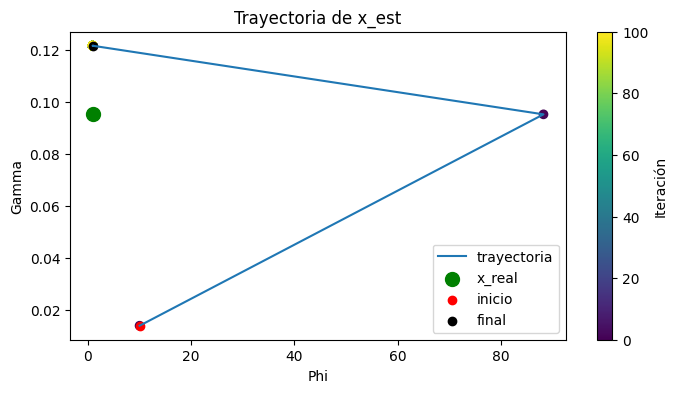

In [7]:
plt.figure(figsize=(8,4))
plt.title("Trayectoria de x_est")
plt.xlabel("Phi")
plt.ylabel("Gamma")

# trayectoria
plt.plot(x_est[0,:], x_est[1,:], '-', markersize=3, label='trayectoria')

# color por iteración
c = np.arange(M)
sc = plt.scatter(x_est[0,:], x_est[1,:], c=c, cmap='viridis')

# puntos clave
plt.scatter(x[0], x[1], c='green', label='x_real', s=100)
plt.scatter(x_est[0,0], x_est[1,0], c='red', label='inicio')
plt.scatter(x_est[0,-1], x_est[1,-1], c='black', label='final')

plt.colorbar(sc, label='Iteración')
plt.legend()
plt.show()

In [11]:
# Probamos con las fórmulas 1.81 -> 1.82
alpha = 1e3
beta = np.array([
    [1e-2],
    [1e-2]
])
print(beta, alpha)

# H_1 y W_1
H = np.hstack((y_meas[0], u[0])).reshape(1,-1)
W = np.array([[1]]) # Revienta porque y_meas[0] = 1

x_est = np.zeros((len(x),M)) 

P_k = np.linalg.inv(1/(alpha**2)*np.eye(H.shape[1]) + H.T @ W @ H)
print(P_k)
x_est[:,0] = (P_k @ (1/alpha * beta + H.T @ W @ y_meas[0].reshape(1,-1))).reshape((x_est[:,0].shape))

for it in range(1, y_meas.shape[0]): # it = k+1
    # Definimos H_k+1 y W_k+1
    H = np.hstack((y_meas[it-1], u[it-1])).reshape(1,-1)
    sigma = np.std(y_meas[:it]) + 1e-6
    W = np.array([[1/(sigma**2)]])

    # Actualizamos P_k+1 y K_k+1 antes de hacer x_k+1
    comp1 = H @ P_k @ H.T + np.linalg.inv(W)
    K = P_k @ H.T @ np.linalg.inv(H @ P_k @ H.T + np.linalg.inv(W))
    P_k = (np.eye(P_k.shape[0]) - K @ H) @ P_k

    x_k = x_est[:, it-1]
    x_est[:,it] = x_k + K @ (y_meas[it] - H @ x_k)
    
print(f"X_real: {x}")
print(f"X_est final: {x_est[:,-1].flatten()}")

[[0.01]
 [0.01]] 1000.0
[[1.e+06 0.e+00]
 [0.e+00 1.e-04]]
X_real: [0.9048, 0.0952]
X_est final: [0.90480019 0.0952    ]


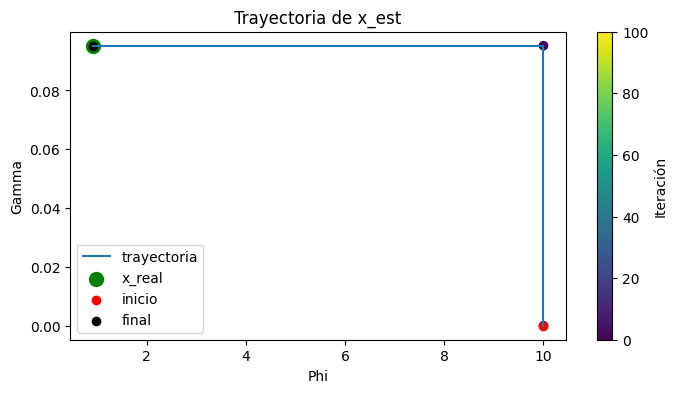

In [9]:
plt.figure(figsize=(8,4))
plt.title("Trayectoria de x_est")
plt.xlabel("Phi")
plt.ylabel("Gamma")

# trayectoria
plt.plot(x_est[0,:], x_est[1,:], '-', markersize=3, label='trayectoria')

# color por iteración
c = np.arange(M)
sc = plt.scatter(x_est[0,:], x_est[1,:], c=c, cmap='viridis')

# puntos clave
plt.scatter(x[0], x[1], c='green', label='x_real', s=100)
plt.scatter(x_est[0,0], x_est[1,0], c='red', label='inicio')
plt.scatter(x_est[0,-1], x_est[1,-1], c='black', label='final')

plt.colorbar(sc, label='Iteración')
plt.legend()
plt.show()